In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!df -h /content/drive/MyDrive

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


In [2]:
!mkdir -p /content/drive/MyDrive/isic_data
!cp -r isic_data/* /content/drive/MyDrive/isic_data/

cp: cannot stat 'isic_data/*': No such file or directory


In [ ]:
!ls /content/drive/MyDrive/isic_data
!du -sh /content/drive/MyDrive/isic_data

4.0K	/content/drive/MyDrive/isic_data


In [4]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive/isic_data
!du -sh /content/drive/MyDrive/isic_data

ISIC2018_Task1-2_Training_Input  ISIC2018_Task1_Training_GroundTruth
11G	/content/drive/MyDrive/isic_data


In [6]:
!du -sh /content/drive/MyDrive/isic_data
!ls /content/drive/MyDrive/isic_data/ISIC2018_Task1-2_Training_Input | wc -l
!ls /content/drive/MyDrive/isic_data/ISIC2018_Task1_Training_GroundTruth | wc -l

11G	/content/drive/MyDrive/isic_data
2596
2596


In [7]:
import os

img_dir = "/content/drive/MyDrive/isic_data/ISIC2018_Task1-2_Training_Input"
mask_dir = "/content/drive/MyDrive/isic_data/ISIC2018_Task1_Training_GroundTruth"

img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
print(len(img_files))

2594


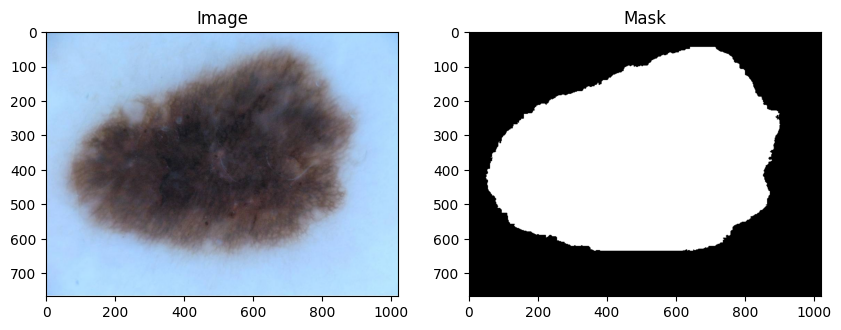

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(f"{img_dir}/ISIC_0000000.jpg")
mask = Image.open(f"{mask_dir}/ISIC_0000000_segmentation.png")

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(img); ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Mask")
plt.show()

In [9]:
!pip install albumentations -q
import albumentations as A
print(A.__version__)

2.0.8


In [10]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np

class ISICDataset(Dataset):
    def __init__(self,img_files,img_dir,mask_dir,transform=None):
      self.transform=transform
      self.img_files=img_files
      self.img_dir=img_dir
      self.mask_dir=mask_dir

    def __len__(self):
      return len(self.img_files)

    def __getitem__(self,idx):
      img_name=self.img_files[idx]
      mask_name=img_name.replace(".jpg","_segmentation.png")

      image=cv2.imread(f"{self.img_dir}/{img_name}")
      image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

      mask=cv2.imread(f"{self.mask_dir}/{mask_name}",cv2.IMREAD_GRAYSCALE)
      mask=(mask>127).astype(np.float32)

      if self.transform:
        augmentations=self.transform(image=image,mask=mask)
        image=augmentations["image"]
        mask=augmentations["mask"]
      return image,mask

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])

print(train_transform)
dataset = ISICDataset(img_files, img_dir, mask_dir, transform=train_transform)
img, mask = dataset[0]
print(img.shape, mask.shape)


Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
(256, 256, 3) (256, 256)


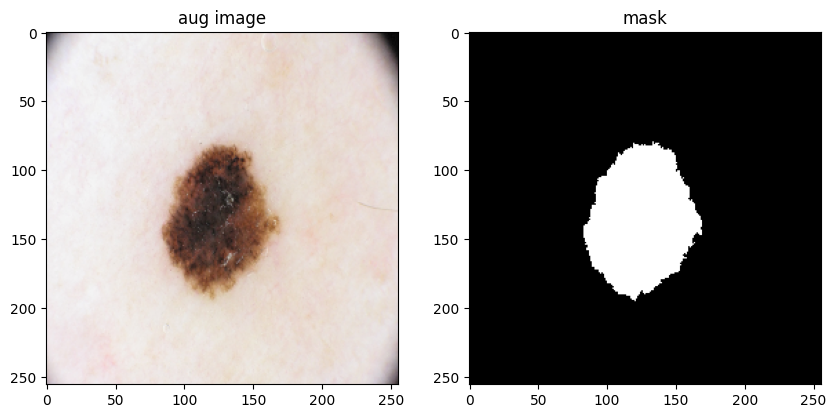

In [11]:
dataset=ISICDataset(img_files,img_dir,mask_dir,transform=train_transform)

img,mask=dataset[122]
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img);ax[0].set_title("aug image")
ax[1].imshow(mask,cmap="gray");ax[1].set_title("mask")
plt.show()

In [12]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1)
    self.relu=nn.ReLU()
    self.conv2=nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1)

  def forward(self,x):
    x=self.conv1(x)
    x=self.relu(x)
    x=self.conv2(x)
    x=self.relu(x)
    return x

block1=ConvBlock(in_channels=3,out_channels=64)
fake_input=torch.randn(1,3,256,256)
output=block1(fake_input)
print(output.shape)

pool=nn.MaxPool2d(kernel_size=2,stride=2)
output=pool(output)
print(output.shape)

block2 = ConvBlock(in_channels=64, out_channels=128)
output2 = block2(output)
print(output2.shape)

pooled_output2 = pool(output2)
print(pooled_output2.shape)

torch.Size([1, 64, 256, 256])
torch.Size([1, 64, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 64, 64])


In [15]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.block1=ConvBlock(3,64)
    self.block2=ConvBlock(64,128)
    self.block3=ConvBlock(128,256)
    self.block4=ConvBlock(256,512)
    self.pool=nn.MaxPool2d(kernel_size=2,stride=2)

  def forward(self,x):
    skip1=self.block1(x)
    x=self.pool(skip1)

    skip2=self.block2(x)
    x=self.pool(skip2)

    skip3=self.block3(x)
    x=self.pool(skip3)

    skip4=self.block4(x)
    x=self.pool(skip4)

    return x,[skip1,skip2,skip3,skip4]

encoder=Encoder()
fake_input=torch.randn(1,3,256,256)
bottleneck_input,skips=encoder(fake_input)


print(bottleneck_input.shape)
for i,s in enumerate(skips):
  print(f"skip{i+1}: {s.shape}")


torch.Size([1, 512, 16, 16])
skip1: torch.Size([1, 64, 256, 256])
skip2: torch.Size([1, 128, 128, 128])
skip3: torch.Size([1, 256, 64, 64])
skip4: torch.Size([1, 512, 32, 32])
